# 🌪️ EDA — NLP with Disaster Tweets (Kaggle)

**Objectif** : Explorer le dataset Kaggle *Natural Language Processing with Disaster Tweets* pour comprendre les données avant modélisation.

### Plan :
1. Import des librairies
2. Chargement des données
3. Inspection générale
4. Analyse de la variable cible
5. Valeurs manquantes
6. Keyword & Location
7. Features textuelles
8. Prétraitement + Fréquences des mots
9. WordClouds
10. N-grammes
11. TF-IDF
12. Doublons
13. Train vs Test
14. Hashtags / Mentions / URLs
15. Matrice de corrélation
16. Exemples de tweets
17. Résumé & Insights

## 1. Import des librairies

In [10]:
import re
import warnings
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
# Téléchargements NLTK (compatibles toutes versions)
for resource in ['stopwords', 'punkt', 'punkt_tab', 'wordnet', 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords
from nltk.util import ngrams

from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

RANDOM_STATE = 42
print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


In [ ]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

RANDOM_STATE = 42
RAW_PATH = 'tweets.csv' # Adjust if needed

# 1. Chargement
df = pd.read_csv(RAW_PATH)
print(f'Dataset brut : {df.shape}')

# 2. Fonctions de nettoyage (Stateless)
STOPWORDS_EN = set(stopwords.words('english'))

def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_no_stop(text):
    tokens = basic_clean(text).split()
    return [t for t in tokens if t not in STOPWORDS_EN and len(t) > 2]

def clean_location(location):
    if pd.isna(location) or location == '': return 'Unknown'
    location = str(location).strip().lower()
    if 'usa' in location or 'united states' in location: return 'USA'
    if 'uk' in location or 'united kingdom' in location: return 'UK'
    return location.title()

# 3. Application du nettoyage global
print('Nettoyage en cours...')
df['clean_text'] = df['text'].apply(basic_clean)
df['tokens']     = df['text'].apply(tokenize_no_stop)
df['clean_location'] = df['location'].apply(clean_location)

# 4. Split
train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['target']
)
train = train.reset_index(drop=True)
test  = test.reset_index(drop=True)

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
train.head()

## 3. Inspection générale

In [13]:
print('=== .info() ===')
train.info()

=== .info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9096 entries, 0 to 9095
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        9096 non-null   int64 
 1   keyword   9096 non-null   object
 2   location  6371 non-null   object
 3   text      9096 non-null   object
 4   target    9096 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 355.4+ KB


In [14]:
print('=== .describe(include=all) ===')
train.describe(include='all')

=== .describe(include=all) ===


,id,keyword,location,text,target
count,9096.000000,9096,6371,9096,9096.000000
unique,NaN,219,3751,9008,NaN
top,NaN,thunderstorm,United States,I want to help you with my project to save the Caribbean Sea from floods and hurricanes https://t.co/qD8Om9NqQK,NaN
freq,NaN,74,79,3,NaN
mean,5692.824318,NaN,NaN,NaN,0.185906
std,3286.126715,NaN,NaN,NaN,0.389052
min,1.000000,NaN,NaN,NaN,0.000000
25%,2842.750000,NaN,NaN,NaN,0.000000
50%,5703.500000,NaN,NaN,NaN,0.000000
75%,8534.250000,NaN,NaN,NaN,0.000000


In [15]:
print('=== Premier tweet ===')
print(train['text'].iloc[0])

=== Premier tweet ===
Had a dream (nightmare ) last night that I worked at McDonald's again and honestly I've woken up traumatised


## 4. Analyse de la variable cible (`target`)

Distribution de la variable target :
        Count  Percentage (%)
target                       
0        7405           81.41
1        1691           18.59


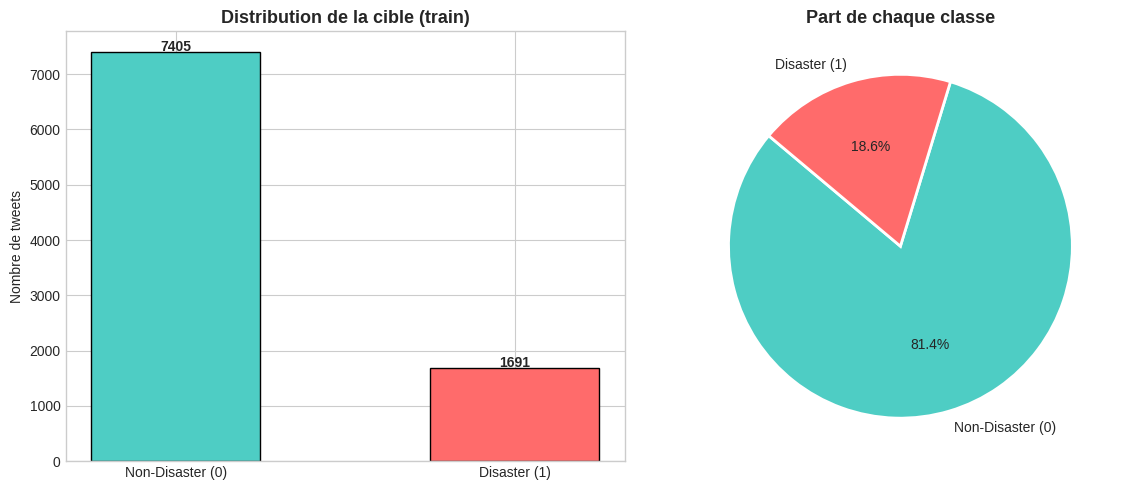

In [16]:
target_counts = train['target'].value_counts()
target_pct    = train['target'].value_counts(normalize=True) * 100

print('Distribution de la variable target :')
print(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Non-Disaster (0)', 'Disaster (1)']
colors = ['#4ECDC4', '#FF6B6B']

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribution de la cible (train)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de tweets')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Part de chaque classe', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Valeurs manquantes

In [17]:
def missing_summary(df, name):
    missing     = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    summary = pd.DataFrame({'Missing': missing, 'Missing (%)': missing_pct.round(2)})
    print(f'\n=== Valeurs manquantes — {name} ===')
    return summary[summary['Missing'] > 0]

display(missing_summary(train, 'Train'))
display(missing_summary(test,  'Test'))


=== Valeurs manquantes — Train ===


,Missing,Missing (%)
location,2725,29.96



=== Valeurs manquantes — Test ===


,Missing,Missing (%)
location,693,30.47


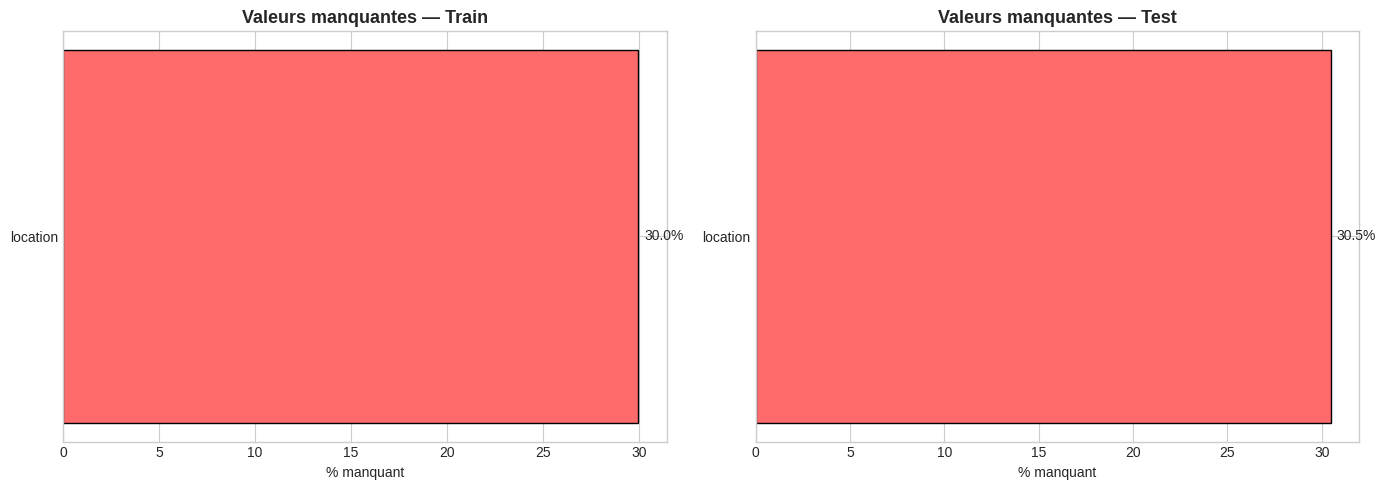

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [train, test], ['Train', 'Test']):
    mp = df.isnull().mean() * 100
    mp = mp[mp > 0]
    if len(mp) > 0:
        ax.barh(mp.index, mp.values, color='#FF6B6B', edgecolor='black')
        ax.set_xlabel('% manquant')
        ax.set_title(f'Valeurs manquantes — {title}', fontsize=13, fontweight='bold')
        for i, v in enumerate(mp.values):
            ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
    else:
        ax.text(0.5, 0.5, 'Aucune valeur manquante', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Valeurs manquantes — {title}', fontsize=13)

plt.tight_layout()
plt.show()

## 6. Keyword & Location

### 6.1 Keyword

Keywords uniques (train) : 219
Keywords uniques (test)  : 219


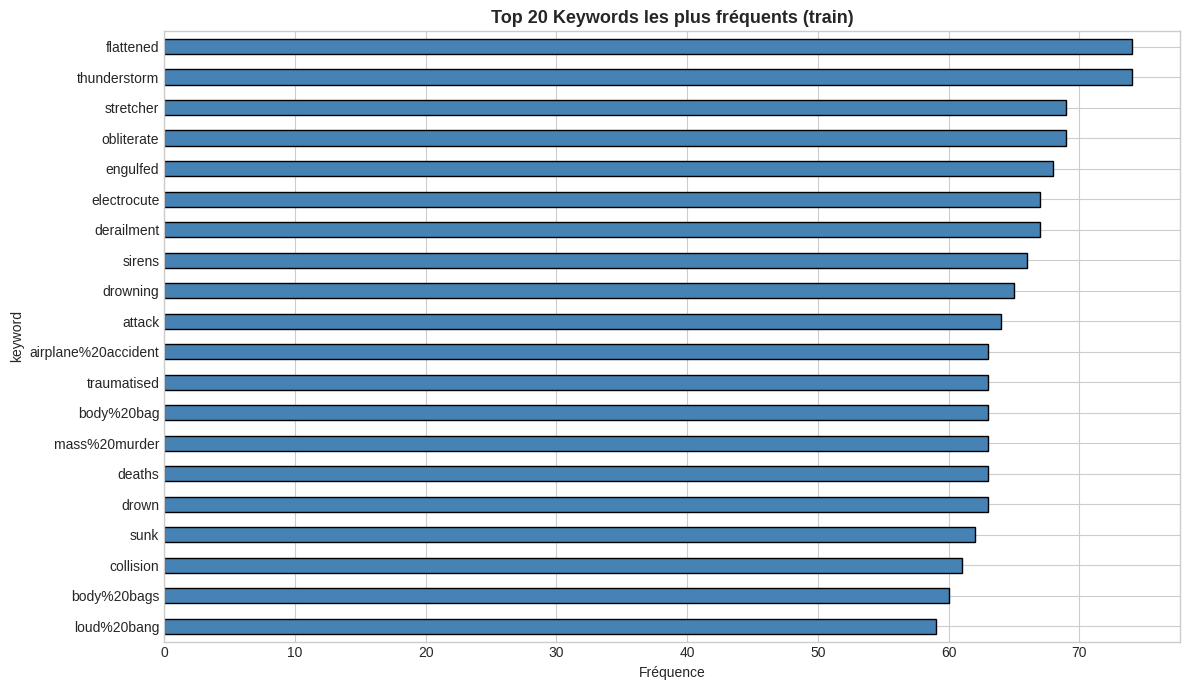

In [19]:
print(f"Keywords uniques (train) : {train['keyword'].nunique()}")
print(f"Keywords uniques (test)  : {test['keyword'].nunique()}")

top_kw = train['keyword'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
top_kw.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 20 Keywords les plus fréquents (train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

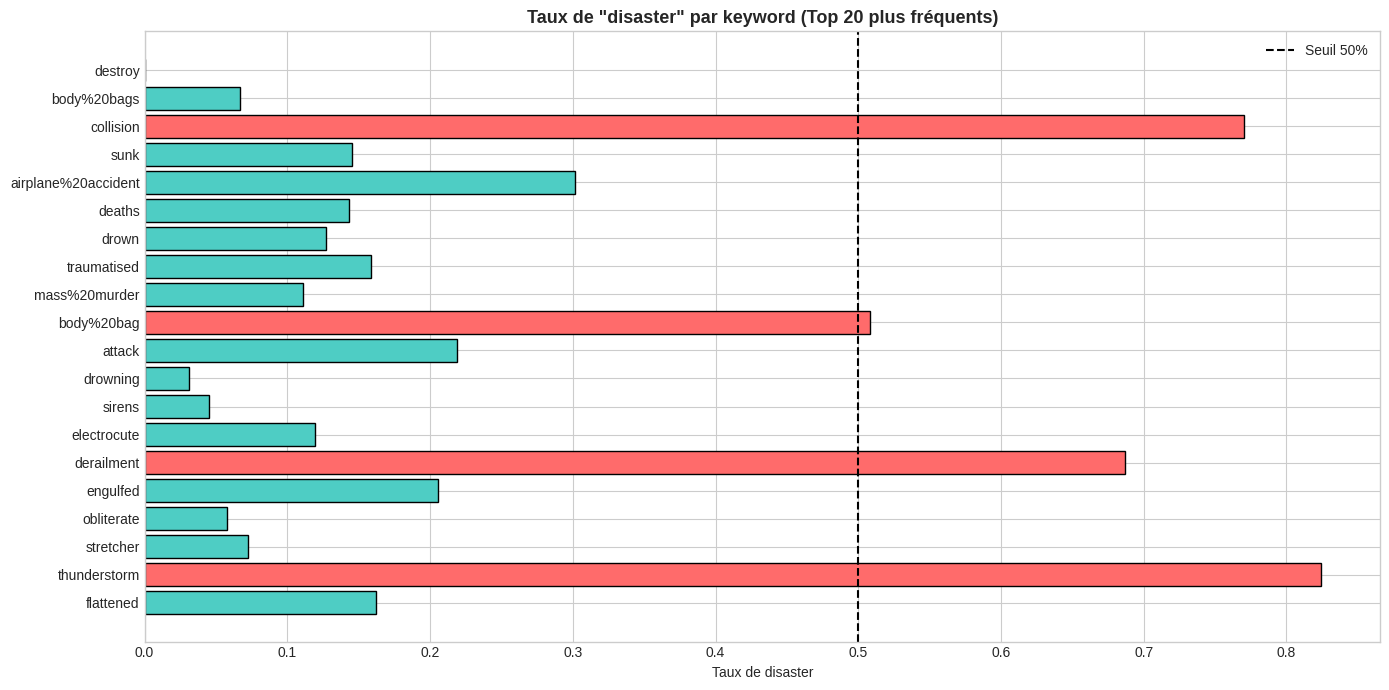

In [20]:
# Taux de disaster per keyword (top 20)
kw_stats = (
    train.groupby('keyword')['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'disaster_rate', 'count': 'total'})
    .sort_values('total', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(kw_stats.index, kw_stats['disaster_rate'],
        color=['#FF6B6B' if r > 0.5 else '#4ECDC4' for r in kw_stats['disaster_rate']],
        edgecolor='black')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Seuil 50%')
ax.set_xlabel('Taux de disaster')
ax.set_title('Taux de "disaster" par keyword (Top 20 plus fréquents)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Location

Locations uniques (train) : 3751


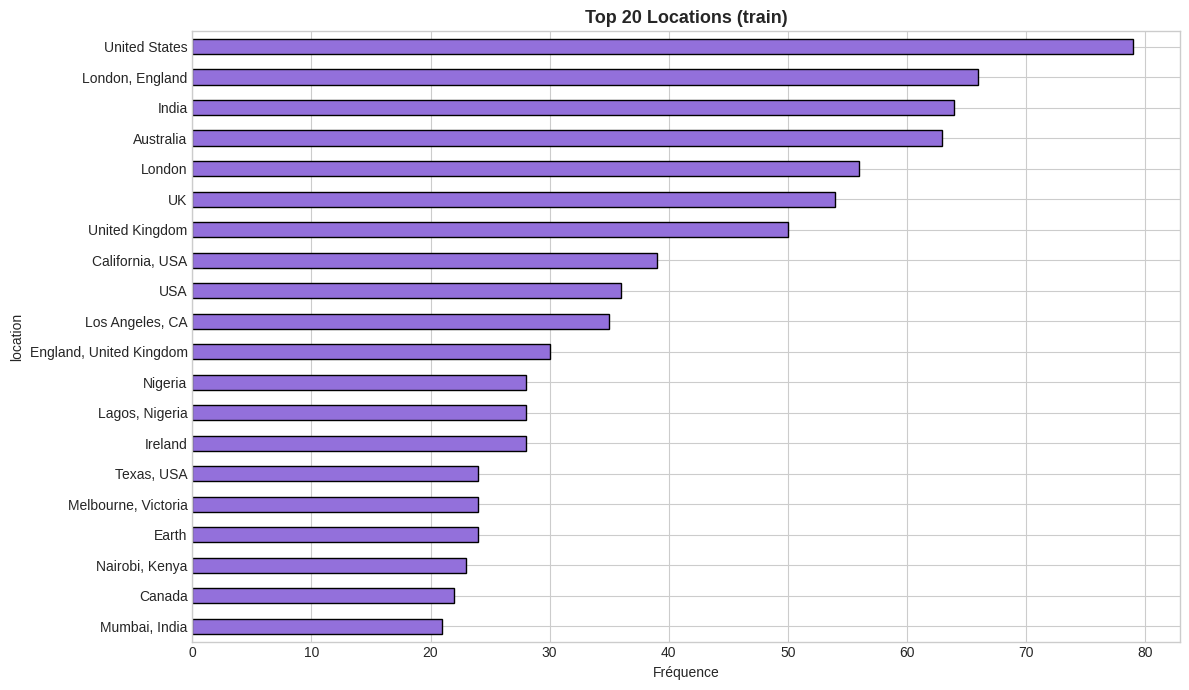

In [21]:
print(f"Locations uniques (train) : {train['location'].nunique()}")

top_loc = train['location'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
top_loc.sort_values().plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Top 20 Locations (train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

## 7. Features textuelles

In [22]:
def extract_text_features(df):
    df = df.copy()
    df['char_count']        = df['text'].str.len()
    df['word_count']        = df['text'].str.split().str.len()
    df['unique_word_count'] = df['text'].apply(lambda x: len(set(str(x).split())))
    df['avg_word_length']   = df['text'].apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0
    )
    df['url_count']         = df['text'].apply(lambda x: len(re.findall(r'http\S+', str(x))))
    df['mention_count']     = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
    df['hashtag_count']     = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
    df['exclamation_count'] = df['text'].str.count('!')
    df['question_count']    = df['text'].str.count('\\?')
    df['digit_count']       = df['text'].apply(lambda x: sum(c.isdigit() for c in str(x)))
    df['uppercase_count']   = df['text'].apply(lambda x: sum(c.isupper() for c in str(x)))
    return df

train = extract_text_features(train)
test  = extract_text_features(test)
print("✅ Features textuelles ajoutées")
train.head(2)

✅ Features textuelles ajoutées


,id,keyword,location,text,target,char_count,word_count,unique_word_count,avg_word_length,url_count,mention_count,hashtag_count,exclamation_count,question_count,digit_count,uppercase_count
0,10497,traumatised,"York, England",Had a dream (nightmare ) last night that I worked at McDonald's again and honestly I've woken up traumatised,0,108,19,19,4.736842,0,0,0,0,0,0,5
1,1462,body%20bags,Upstate NY,"There it is, on cue! Body Bags Burrow with the strike! #GeauxTigahs",0,67,12,12,4.666667,0,0,1,2,0,0,6


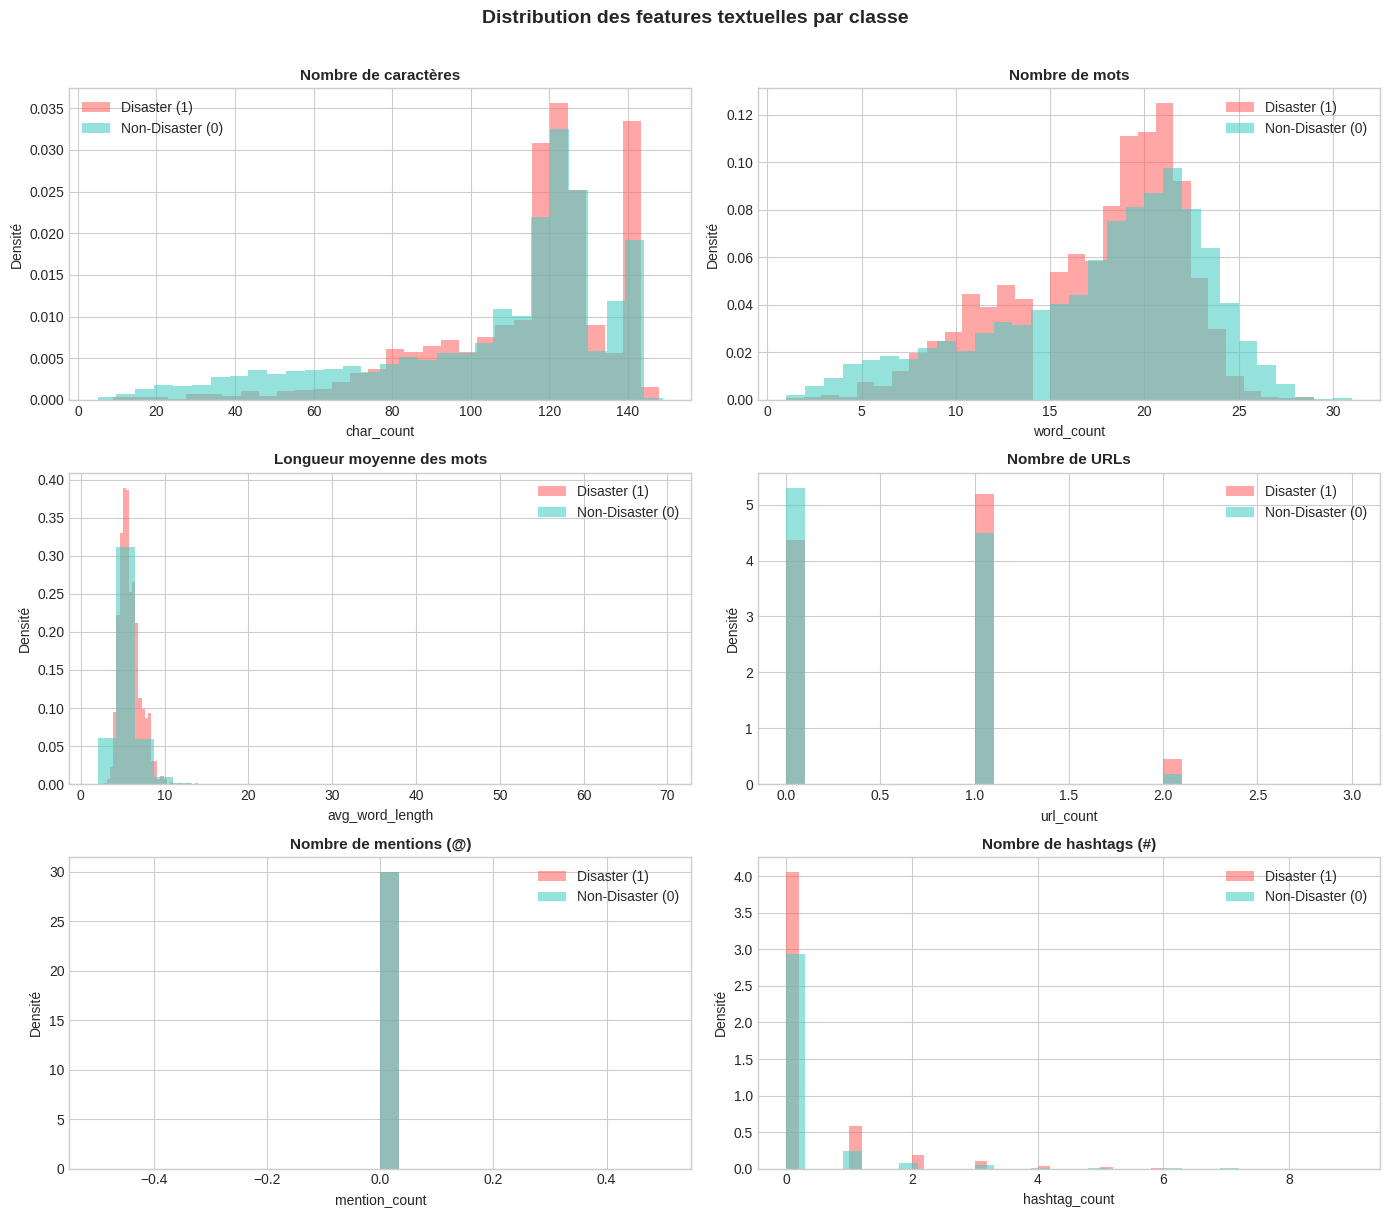

In [23]:
# Distributions par classe
disaster     = train[train['target'] == 1]
non_disaster = train[train['target'] == 0]

features_to_plot = [
    ('char_count',      'Nombre de caractères'),
    ('word_count',      'Nombre de mots'),
    ('avg_word_length', 'Longueur moyenne des mots'),
    ('url_count',       'Nombre de URLs'),
    ('mention_count',   'Nombre de mentions (@)'),
    ('hashtag_count',   'Nombre de hashtags (#)'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (feat, label) in enumerate(features_to_plot):
    axes[i].hist(disaster[feat],     bins=30, alpha=0.6, color='#FF6B6B', label='Disaster (1)',     density=True)
    axes[i].hist(non_disaster[feat], bins=30, alpha=0.6, color='#4ECDC4', label='Non-Disaster (0)', density=True)
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Densité')
    axes[i].legend()

plt.suptitle('Distribution des features textuelles par classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 8.2 Fréquences globales (tous tweets)

In [28]:
# Fréquence globale (tous les tweets du train)
all_tokens = [t for tokens in train['tokens'] for t in tokens]
word_freq  = Counter(all_tokens)

print(f'Vocabulaire (tokens uniques, sans stopwords) : {len(word_freq)}')
print('\nTop 30 mots les plus fréquents :')
print(word_freq.most_common(30))

Vocabulaire (tokens uniques, sans stopwords) : 17788

Top 30 mots les plus fréquents :
[('amp', 476), ('people', 446), ('like', 424), ('one', 358), ('get', 256), ('fire', 243), ('new', 224), ('time', 207), ('would', 196), ('know', 187), ('iran', 185), ('need', 181), ('first', 170), ('years', 166), ('see', 162), ('trump', 161), ('today', 159), ('emergency', 156), ('think', 153), ('body', 152), ('man', 152), ('back', 152), ('two', 151), ('australia', 150), ('still', 150), ('fires', 145), ('world', 142), ('storm', 142), ('day', 142), ('news', 140)]


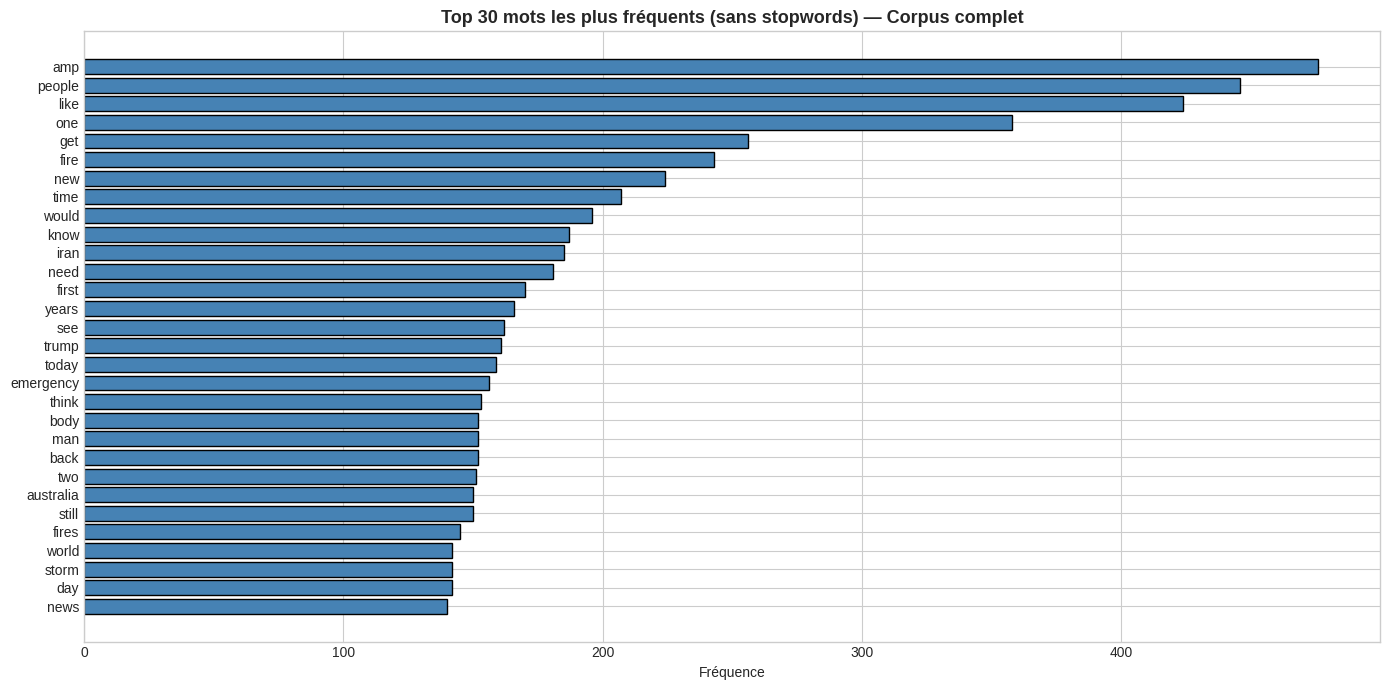

In [29]:
top30 = pd.DataFrame(word_freq.most_common(30), columns=['word', 'count'])

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(top30['word'][::-1], top30['count'][::-1], color='steelblue', edgecolor='black')
ax.set_title('Top 30 mots les plus fréquents (sans stopwords) — Corpus complet', fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

### 8.3 Fréquences par classe

In [30]:
# Fréquences séparées par classe
tokens_disaster     = [t for tokens in disaster['tokens']     for t in tokens]
tokens_non_disaster = [t for tokens in non_disaster['tokens'] for t in tokens]

freq_disaster     = Counter(tokens_disaster)
freq_non_disaster = Counter(tokens_non_disaster)

print(f'Tokens disaster     : {len(tokens_disaster)} ({len(freq_disaster)} uniques)')
print(f'Tokens non-disaster : {len(tokens_non_disaster)} ({len(freq_non_disaster)} uniques)')

Tokens disaster     : 16800 (5093 uniques)
Tokens non-disaster : 66111 (15999 uniques)


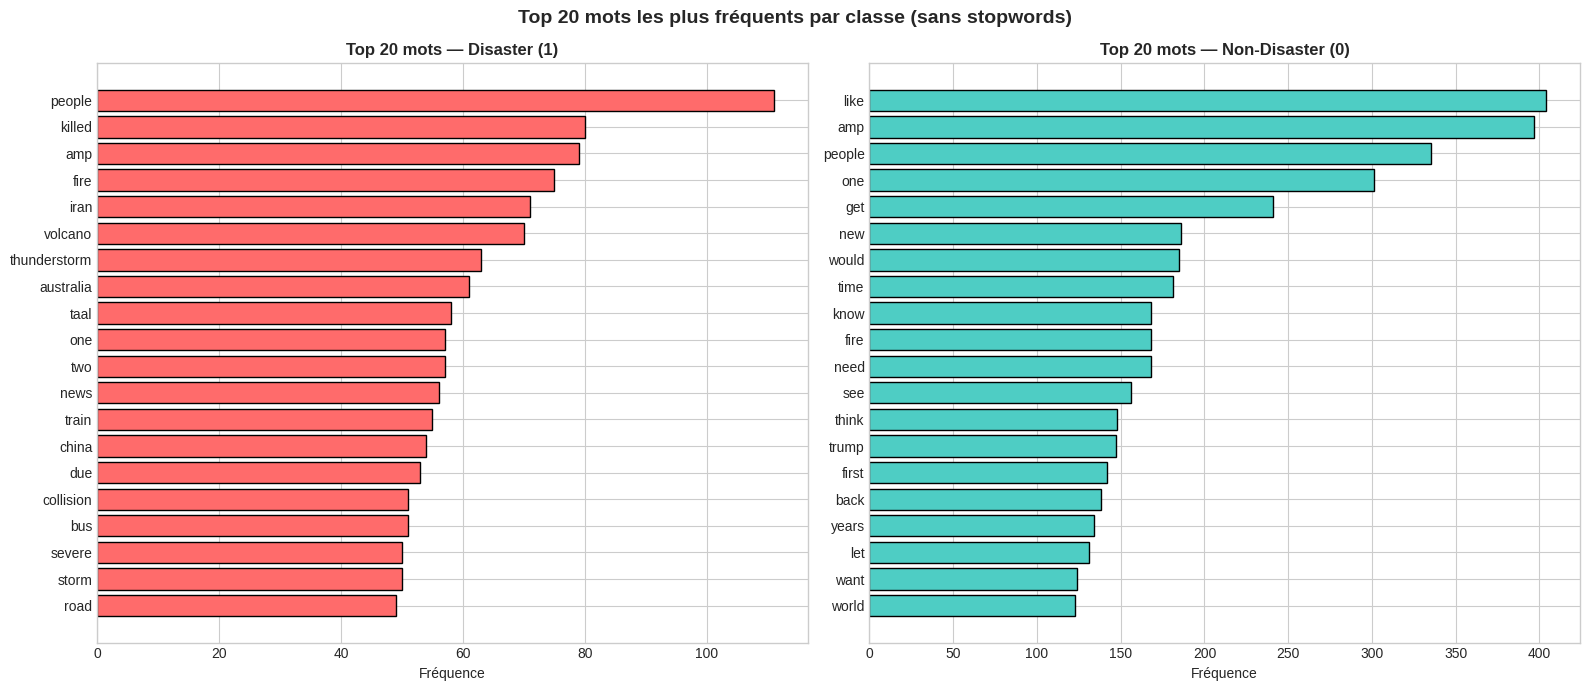

In [31]:
top_dis  = pd.DataFrame(freq_disaster.most_common(20),     columns=['word', 'count'])
top_ndis = pd.DataFrame(freq_non_disaster.most_common(20), columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_dis['word'][::-1], top_dis['count'][::-1], color='#FF6B6B', edgecolor='black')
axes[0].set_title('Top 20 mots — Disaster (1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fréquence')

axes[1].barh(top_ndis['word'][::-1], top_ndis['count'][::-1], color='#4ECDC4', edgecolor='black')
axes[1].set_title('Top 20 mots — Non-Disaster (0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fréquence')

plt.suptitle('Top 20 mots les plus fréquents par classe (sans stopwords)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. WordClouds par classe

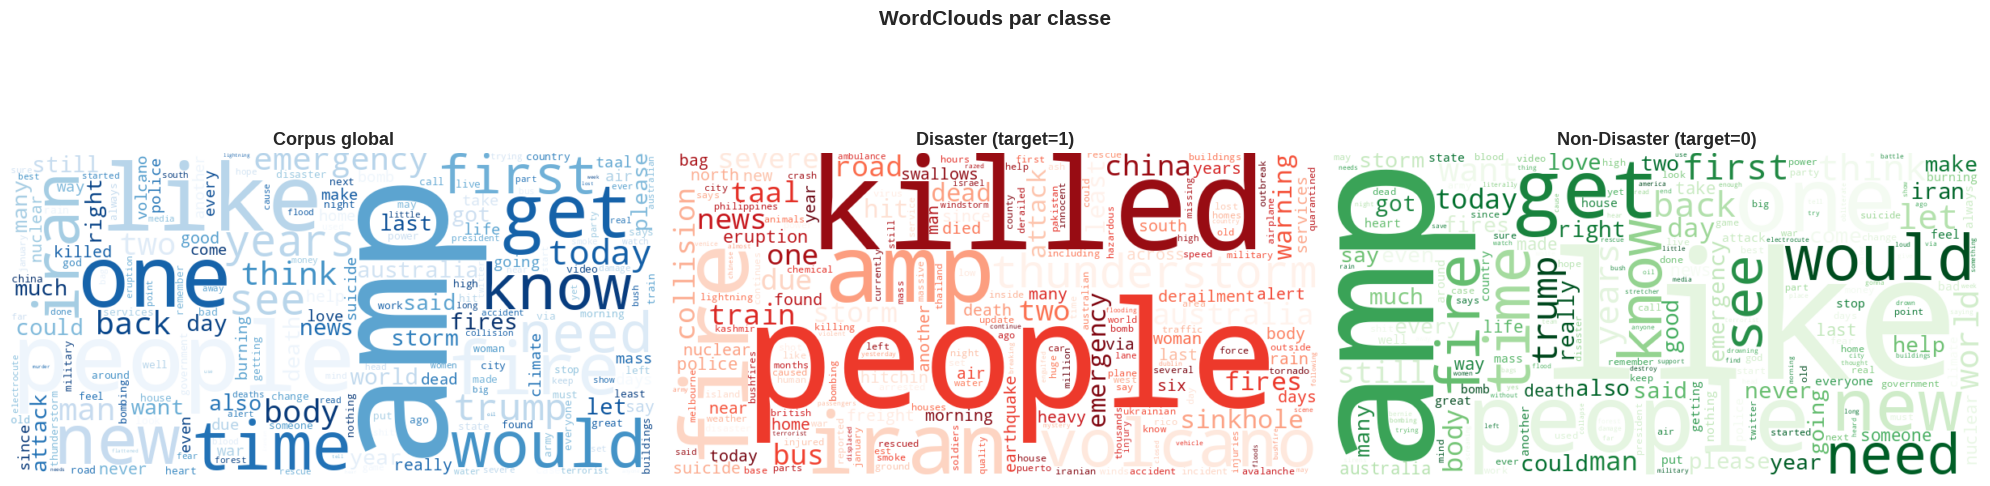

In [32]:
def make_wordcloud(word_dict, background_color='white', colormap='Blues'):
    wc = WordCloud(
        background_color=background_color,
        max_words=200,
        colormap=colormap,
        collocations=False,
        width=800, height=400
    ).generate_from_frequencies(word_dict)
    return wc

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Global
wc_all = make_wordcloud(dict(word_freq), colormap='Blues')
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].set_title('Corpus global', fontsize=13, fontweight='bold')
axes[0].axis('off')

# Disaster
wc_dis = make_wordcloud(dict(freq_disaster), colormap='Reds')
axes[1].imshow(wc_dis, interpolation='bilinear')
axes[1].set_title('Disaster (target=1)', fontsize=13, fontweight='bold')
axes[1].axis('off')

# Non-Disaster
wc_ndis = make_wordcloud(dict(freq_non_disaster), colormap='Greens')
axes[2].imshow(wc_ndis, interpolation='bilinear')
axes[2].set_title('Non-Disaster (target=0)', fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle('WordClouds par classe', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. N-grammes

### 10.1 Bigrammes

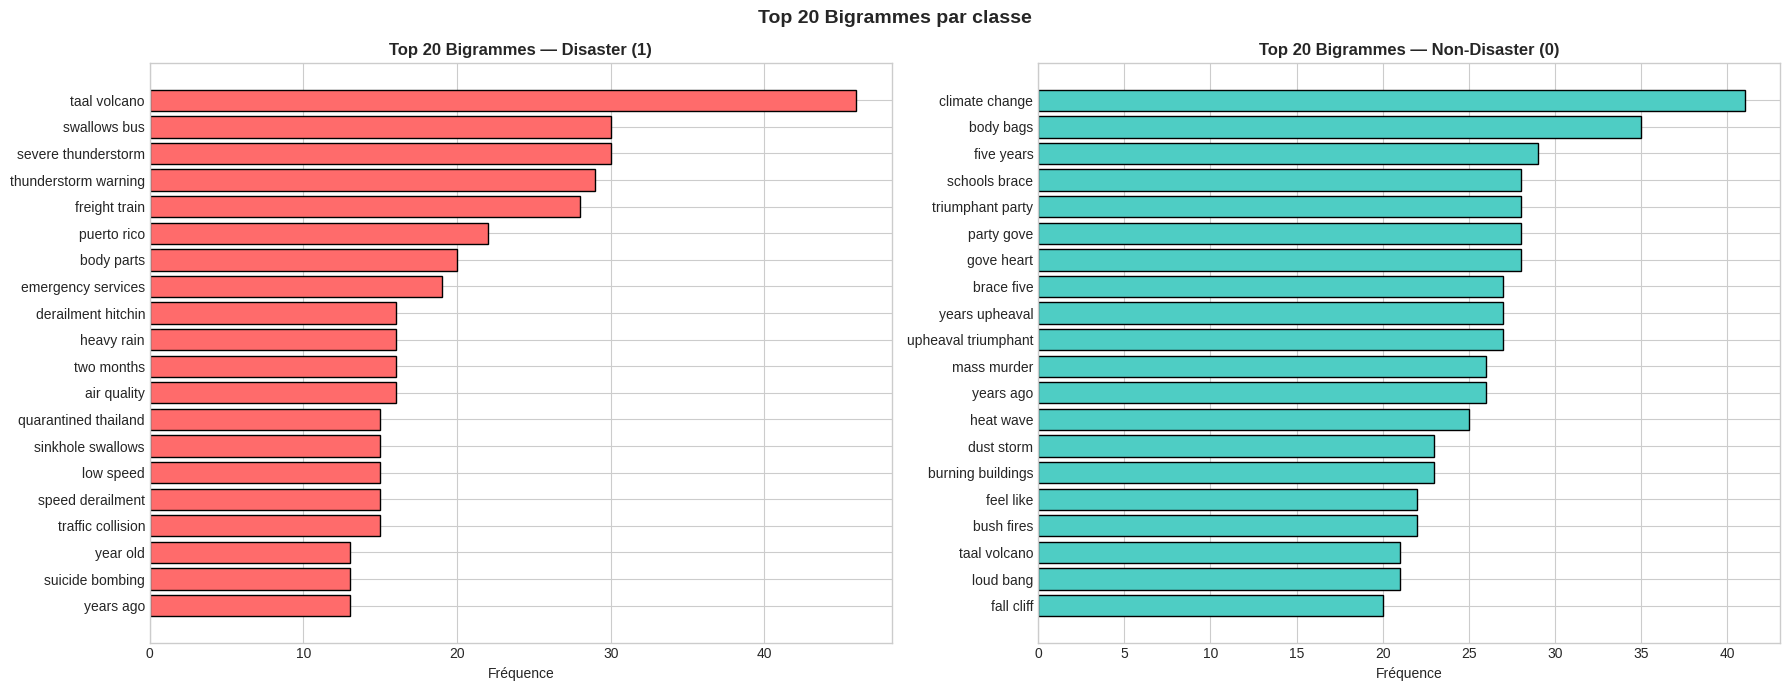

In [33]:
def get_ngram_freq(token_series, n=2, top_k=20):
    all_ngrams = []
    for tokens in token_series:
        all_ngrams.extend(list(ngrams(tokens, n)))
    ngram_freq = Counter(all_ngrams)
    top = pd.DataFrame(
        [(' '.join(gram), count) for gram, count in ngram_freq.most_common(top_k)],
        columns=['ngram', 'count']
    )
    return top

bi_dis  = get_ngram_freq(disaster['tokens'],     n=2)
bi_ndis = get_ngram_freq(non_disaster['tokens'], n=2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(bi_dis['ngram'][::-1], bi_dis['count'][::-1], color='#FF6B6B', edgecolor='black')
axes[0].set_title('Top 20 Bigrammes — Disaster (1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fréquence')

axes[1].barh(bi_ndis['ngram'][::-1], bi_ndis['count'][::-1], color='#4ECDC4', edgecolor='black')
axes[1].set_title('Top 20 Bigrammes — Non-Disaster (0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fréquence')

plt.suptitle('Top 20 Bigrammes par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Trigrammes

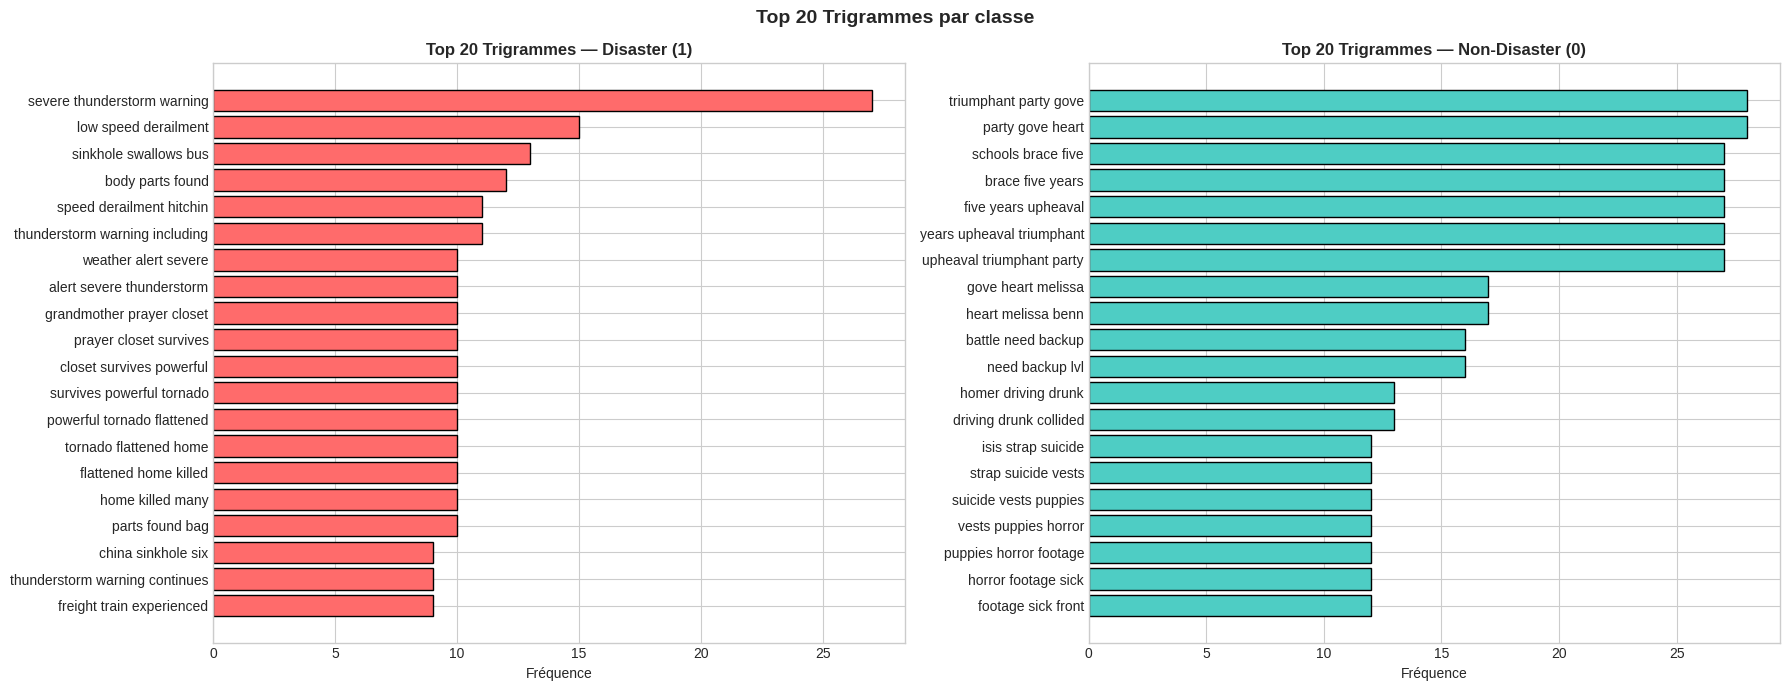

In [34]:
tri_dis  = get_ngram_freq(disaster['tokens'],     n=3)
tri_ndis = get_ngram_freq(non_disaster['tokens'], n=3)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(tri_dis['ngram'][::-1], tri_dis['count'][::-1], color='#FF6B6B', edgecolor='black')
axes[0].set_title('Top 20 Trigrammes — Disaster (1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fréquence')

axes[1].barh(tri_ndis['ngram'][::-1], tri_ndis['count'][::-1], color='#4ECDC4', edgecolor='black')
axes[1].set_title('Top 20 Trigrammes — Non-Disaster (0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fréquence')

plt.suptitle('Top 20 Trigrammes par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Doublons

In [37]:
dup_text = train[train.duplicated('text', keep=False)]
print(f'Tweets en doublon (texte identique) : {len(dup_text)} ({len(dup_text)/len(train)*100:.1f}%)')

dup_conflict = (
    train.groupby('text')['target']
    .nunique()
    .reset_index()
    .query('target > 1')
)
print(f'Tweets avec labels conflictuels : {len(dup_conflict)}')

if len(dup_conflict) > 0:
    print('\nExemples de tweets ambigus :')
    conflict_examples = train[train['text'].isin(dup_conflict['text'].head(3))]
    print(conflict_examples[['text', 'target']].to_string())

Tweets en doublon (texte identique) : 175 (1.9%)
Tweets avec labels conflictuels : 2

Exemples de tweets ambigus :
                                                                                                                      text  target
1075  in case of a nuclear attack to a sprawling bureaucratic agency tasked with mobilizing help in the midst of disaster.       0
2567                                   why is the 0714 HIT-CAM stuck at Royston please? Should e clear of the derailment??       1
5394  in case of a nuclear attack to a sprawling bureaucratic agency tasked with mobilizing help in the midst of disaster.       1
6580                                   why is the 0714 HIT-CAM stuck at Royston please? Should e clear of the derailment??       0


## 14. Hashtags / Mentions / URLs

=== Tweets contenant au moins un pattern special ===
url_count             Total: 48.7%  |  Disaster: 56.4%  |  Non-Disaster: 46.9%
mention_count         Total: 0.0%  |  Disaster: 0.0%  |  Non-Disaster: 0.0%
hashtag_count         Total: 13.2%  |  Disaster: 18.7%  |  Non-Disaster: 11.9%


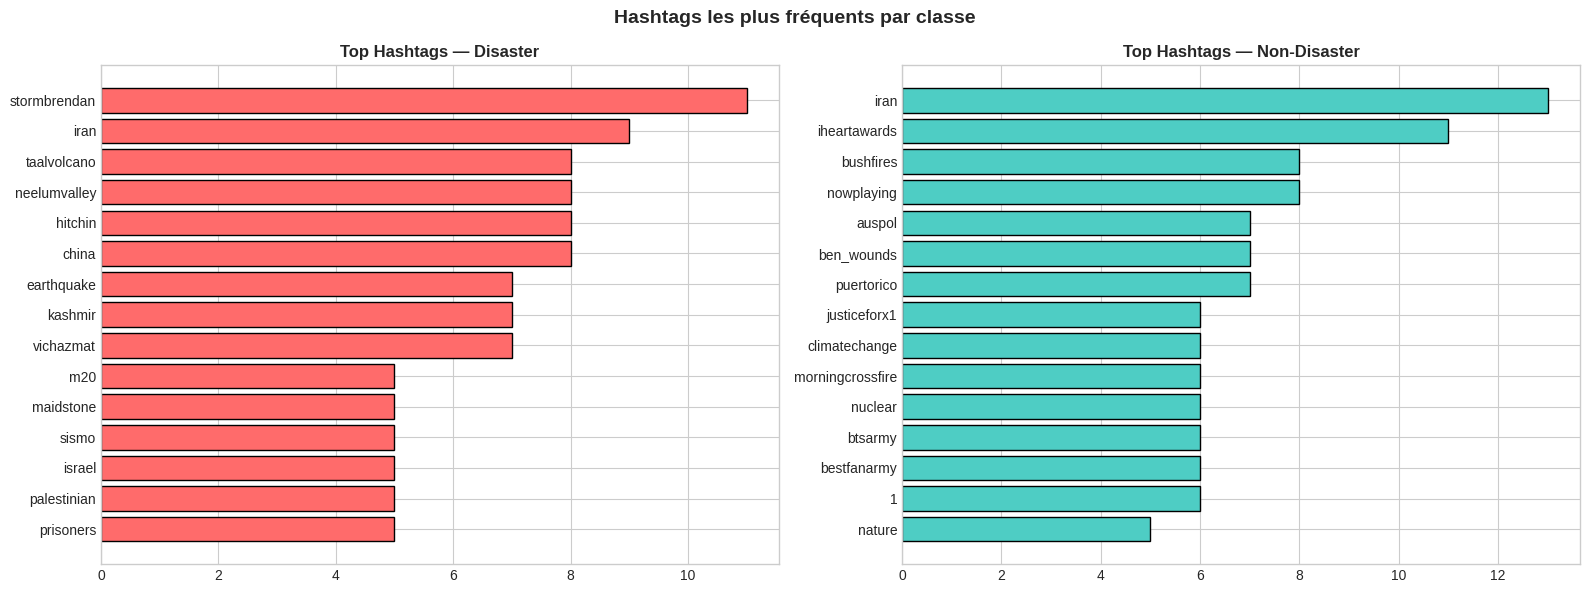

In [39]:
def pct_with(series, min_val=1):
    return (series >= min_val).mean() * 100

print('=== Tweets contenant au moins un pattern special ===')
for feat in ['url_count', 'mention_count', 'hashtag_count']:
    total = pct_with(train[feat])
    dis   = pct_with(disaster[feat])
    ndis  = pct_with(non_disaster[feat])
    print(f'{feat:20s}  Total: {total:.1f}%  |  Disaster: {dis:.1f}%  |  Non-Disaster: {ndis:.1f}%')

def extract_hashtags(text):
    return re.findall(r'#(\w+)', str(text).lower())

hashtags_dis  = [h for text in disaster['text']     for h in extract_hashtags(text)]
hashtags_ndis = [h for text in non_disaster['text'] for h in extract_hashtags(text)]

top_ht_dis  = Counter(hashtags_dis).most_common(15)
top_ht_ndis = Counter(hashtags_ndis).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if top_ht_dis:
    words_d, counts_d = zip(*top_ht_dis)
    axes[0].barh(words_d[::-1], counts_d[::-1], color='#FF6B6B', edgecolor='black')
    axes[0].set_title('Top Hashtags — Disaster', fontsize=12, fontweight='bold')

if top_ht_ndis:
    words_n, counts_n = zip(*top_ht_ndis)
    axes[1].barh(words_n[::-1], counts_n[::-1], color='#4ECDC4', edgecolor='black')
    axes[1].set_title('Top Hashtags — Non-Disaster', fontsize=12, fontweight='bold')

plt.suptitle('Hashtags les plus fréquents par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Matrice de corrélation

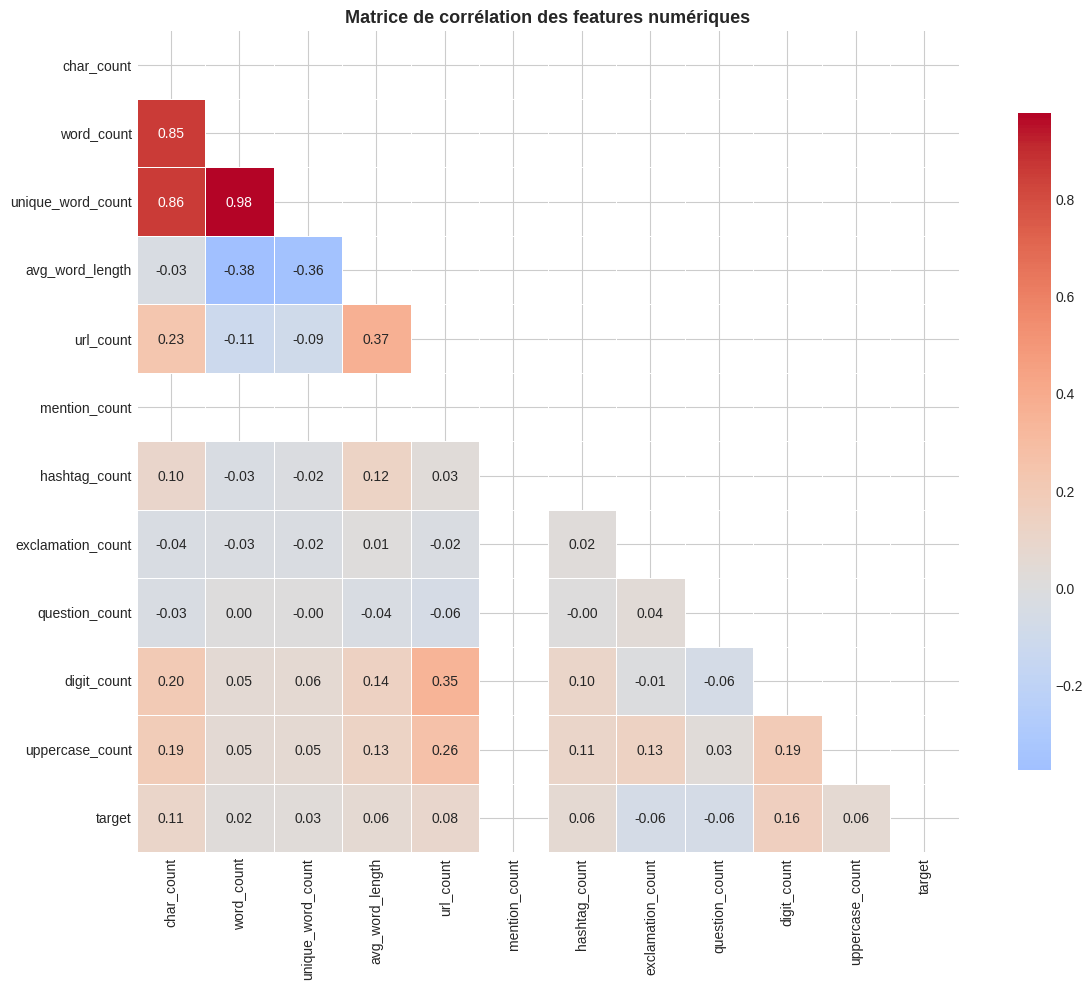

In [40]:
num_features = [
    'char_count', 'word_count', 'unique_word_count',
    'avg_word_length', 'url_count', 'mention_count',
    'hashtag_count', 'exclamation_count', 'question_count',
    'digit_count', 'uppercase_count', 'target'
]

corr_matrix = train[num_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de corrélation des features numériques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Exemples de tweets par classe

In [41]:
print('=== Exemples DISASTER (target=1) ===')
for i, row in disaster[['text', 'keyword']].sample(5, random_state=42).iterrows():
    print(f'[{i}] {row["text"]}')
    print(f'    keyword: {row["keyword"]}')
    print()

print('=== Exemples NON-DISASTER (target=0) ===')
for i, row in non_disaster[['text', 'keyword']].sample(5, random_state=42).iterrows():
    print(f'[{i}] {row["text"]}')
    print(f'    keyword: {row["keyword"]}')
    print()

=== Exemples DISASTER (target=1) ===
[5408] Storm surge from Storm Brendan flooding the harbour on Rathlin Island, off the County Antrim coast. Footage from Dougl…
    keyword: flooding

[8839] Breaking news 3 VW Citi Golfs collided on the m2 highway and 55 coloured guys got injured
    keyword: collided

[6645] Knowing the current situation in the places affected by the eruption of Taal Volcano, many fur babies have been left behind…
    keyword: rescuers

[6437] A look inside a tree that has been struck by lightning. https://t.co/IGcgu00fYm
    keyword: lightning

[8977] If I didn't need my Crutch I would seriously wrap it round someone's bloody head.
    keyword: bloody

=== Exemples NON-DISASTER (target=0) ===
[5334] Won't be for the better. They should be stripped of all titles and go live in some desolate place... With no royal money
    keyword: desolate

[2284] Stanley Kubrick laughing on the burned-down set of The Shining https://t.co/GwbP3vbesy
    keyword: burned

[4296] Get

## 17. Résumé & Insights

## 18. Sauvegarde des données
On exporte les datasets nettoyés pour les utiliser dans nos futurs scripts de modélisation.

In [ ]:
# === SAUVEGARDE DES DONNÉES PRÉTRAITÉES ===
train.to_csv('train_cleaned.csv', index=False)
test.to_csv('test_cleaned.csv', index=False)
print('✅ Fichiers train_cleaned.csv et test_cleaned.csv sauvegardés !')